<a href="https://colab.research.google.com/github/Subhash-2910/flyrank-ML-T1/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Subhash-2910/flyrank-ML-T1/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [19]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Subhash-2910/flyrank-ML-T1.git"
REPO_DIR = "flyrank-ML-T1"

def find_repo_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "data/raw/content_refresh_anonymized.csv").exists():
            return folder
    return None

repo_root = find_repo_root()

if IN_COLAB and repo_root is None:
    if not Path(REPO_DIR).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    repo_root = Path(REPO_DIR)

os.chdir(repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_down"] = (df["trend_direction"] == "down").astype(int)

print("Dataset shape:", df.shape)
print("Overall observed decline rate:", f"{df['is_down'].mean():.1%}")

Dataset shape: (30000, 45)
Overall observed decline rate: 54.2%


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The main numeric fields have heavy tails: many pages have low or zero search demand, while a smaller group has much higher visibility and demand. I use quartile buckets for the checks below so that each comparison has a visible sample size.

,count,mean,std,min,25%,50%,75%,90%,99%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.0,20.00,110.0,2900.00,74000.0
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.0,3615.25,12136.4,73505.83,517715.0
content_age_days,30000.0,256.167800,132.707930,90.0,132.0,236.0,333.00,463.0,537.00,564.0
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.0,20.0,104.00,104.0,106.00,373.0


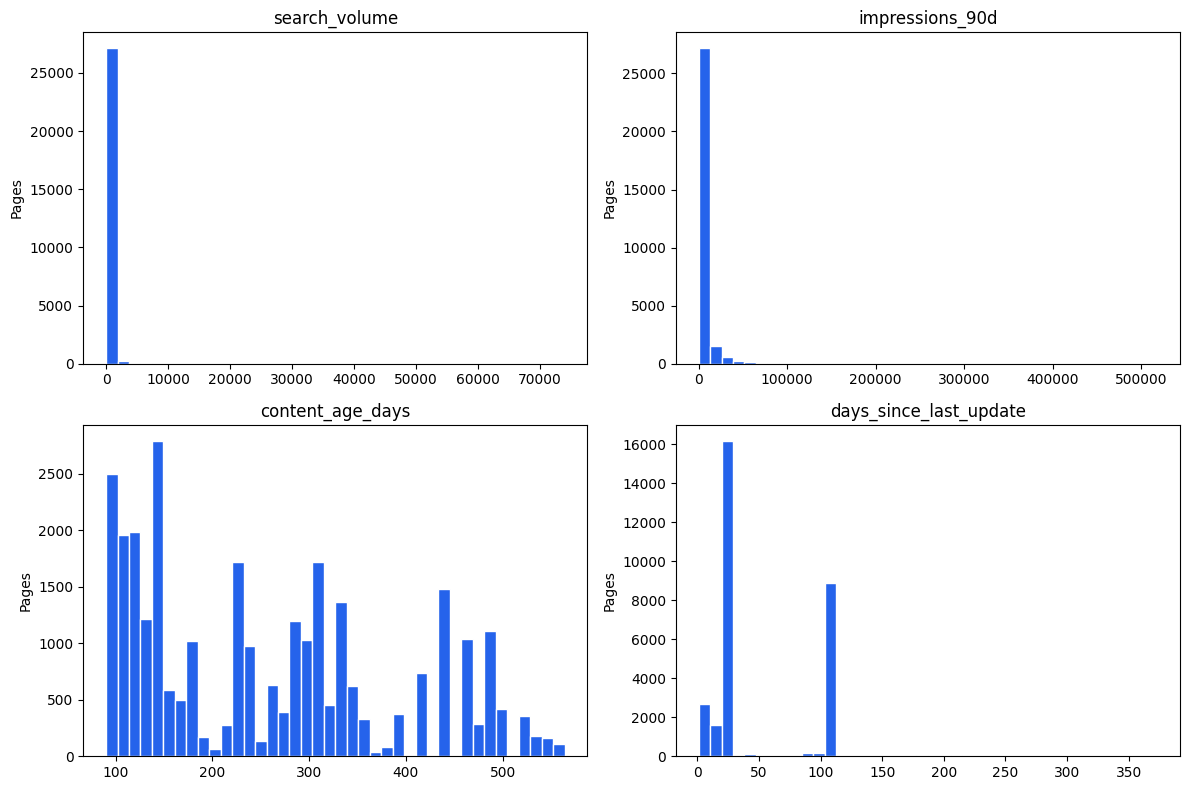

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
distribution_columns = [
    "search_volume",
    "impressions_90d",
    "content_age_days",
    "days_since_last_update",
]

distribution_summary = df[distribution_columns].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.99]
).T

display(distribution_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flat, distribution_columns):
    values = df[column].dropna()
    ax.hist(values, bins=40, color="#2563eb", edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("Pages")

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

I tested three signals against the observed decline direction: staleness, search demand, and current visibility. The verdicts below are descriptive associations in this dataset, not causal evidence that changing a signal will change rankings.

In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def make_bucket_table(data, column, signal_name):
    temp = data[[column, "is_down"]].dropna().copy()

    # Rank first so repeated values, including zeros, can still form buckets.
    temp["bucket"] = pd.qcut(
        temp[column].rank(method="first"),
        q=4,
        labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
    )

    result = (
        temp.groupby("bucket", observed=False)
        .agg(
            n=("is_down", "size"),
            observed_decline_rate=("is_down", "mean"),
            median_signal=(column, "median")
        )
        .reset_index()
    )

    difference = (
        result.loc[result["bucket"] == "Q4 (high)", "observed_decline_rate"].iloc[0]
        - result.loc[result["bucket"] == "Q1 (low)", "observed_decline_rate"].iloc[0]
    )

    if difference >= 0.05:
        verdict = "CONFIRMED"
    elif difference <= -0.05:
        verdict = "OPPOSITE"
    else:
        verdict = "MIXED"

    result["signal"] = signal_name
    result["verdict"] = verdict
    result["high_minus_low_decline_rate"] = difference

    return result

staleness_test = make_bucket_table(
    df, "days_since_last_update", "Staleness: days since last update"
)

demand_test = make_bucket_table(
    df, "search_volume", "Search demand: search volume"
)

visibility_test = make_bucket_table(
    df, "impressions_90d", "Visibility: 90-day impressions"
)

signal_results = pd.concat(
    [staleness_test, demand_test, visibility_test],
    ignore_index=True
)

display(signal_results)

verdict_summary = (
    signal_results.groupby(["signal", "verdict"], as_index=False)
    .agg(high_minus_low_decline_rate=("high_minus_low_decline_rate", "first"))
)

display(verdict_summary)

print(
    "Verdict rule: CONFIRMED if the highest bucket's observed decline rate "
    "is at least 5 percentage points above the lowest bucket; OPPOSITE if "
    "it is at least 5 points lower; otherwise MIXED."
)

,bucket,n,observed_decline_rate,median_signal,signal,verdict,high_minus_low_decline_rate
0,Q1 (low),7500,0.533200,14.0,Staleness: days since last update,CONFIRMED,0.081333
1,Q2,7500,0.542133,20.0,Staleness: days since last update,CONFIRMED,0.081333
2,Q3,7500,0.478400,22.0,Staleness: days since last update,CONFIRMED,0.081333
3,Q4 (high),7500,0.614533,104.0,Staleness: days since last update,CONFIRMED,0.081333
4,Q1 (low),6883,0.628214,0.0,Search demand: search volume,OPPOSITE,-0.118698
5,Q2,6883,0.597995,0.0,Search demand: search volume,OPPOSITE,-0.118698
6,Q3,6883,0.519831,10.0,Search demand: search volume,OPPOSITE,-0.118698
7,Q4 (high),6883,0.509516,90.0,Search demand: search volume,OPPOSITE,-0.118698
8,Q1 (low),7500,0.376000,10.0,Visibility: 90-day impressions,CONFIRMED,0.186000
9,Q2,7500,0.604667,300.0,Visibility: 90-day impressions,CONFIRMED,0.186000


,signal,verdict,high_minus_low_decline_rate
0,Search demand: search volume,OPPOSITE,-0.118698
1,Staleness: days since last update,CONFIRMED,0.081333
2,Visibility: 90-day impressions,CONFIRMED,0.186000


Verdict rule: CONFIRMED if the highest bucket's observed decline rate is at least 5 percentage points above the lowest bucket; OPPOSITE if it is at least 5 points lower; otherwise MIXED.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

The flag-linked test uses staleness, which is a signal behind refresh-review flags. I check whether pages that have gone longer without an update have a higher observed decline rate. This is evidence for prioritising human review, not evidence that refreshing a page causes improvement.

In [22]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
flag_linked_table = staleness_test[[
    "bucket",
    "n",
    "median_signal",
    "observed_decline_rate",
    "verdict"
]].copy()

flag_linked_table = flag_linked_table.rename(columns={
    "bucket": "days_since_last_update_bucket",
    "median_signal": "median_days_since_last_update"
})

display(flag_linked_table)

staleness_verdict = flag_linked_table["verdict"].iloc[0]

print("Flag-linked signal: staleness / days since last update")
print("Verdict:", staleness_verdict)
print("Each bucket includes n so the comparison is transparent.")

,days_since_last_update_bucket,n,median_days_since_last_update,observed_decline_rate,verdict
0,Q1 (low),7500,14.0,0.533200,CONFIRMED
1,Q2,7500,20.0,0.542133,CONFIRMED
2,Q3,7500,22.0,0.478400,CONFIRMED
3,Q4 (high),7500,104.0,0.614533,CONFIRMED


Flag-linked signal: staleness / days since last update
Verdict: CONFIRMED
Each bucket includes n so the comparison is transparent.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The signal checks support using staleness, search demand, and visibility as inputs to a human review queue, but the observed relationships should be treated as directional. A content team should review high-priority pages for outdated information, intent mismatch, and content quality before changing anything. The signals do not prove that an update will improve Google rankings or traffic.

In [23]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
practical_summary = pd.DataFrame({
    "use": [
        "Prioritise human content-review candidates",
        "Use demand and visibility to decide review order",
        "Do not automatically rewrite, publish, remove, or claim causal impact"
    ],
    "evidence": [
        "Observed bucket-level associations",
        "Snapshot measures of demand and visibility",
        "No experiment or causal design was used"
    ]
})

display(practical_summary)

,use,evidence
0,Prioritise human content-review candidates,Observed bucket-level associations
1,Use demand and visibility to decide review order,Snapshot measures of demand and visibility
2,"Do not automatically rewrite, publish, remove,...",No experiment or causal design was used


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.